In [123]:
tr_cols=['Source', 'Temperature (°C)', 'Dewpoint Temperature (°C)',
       'U Wind Component (m/s)', 'V Wind Component (m/s)',
       'Total Precipitation (mm)', 'day_of_week', 'day_of_year', 'Week',
       'temp_dew_diff', 'wind_speed', 'precip_snow_ratio','kwh']
ts_cols=['Source', 'Temperature (°C)', 'Dewpoint Temperature (°C)',
       'U Wind Component (m/s)', 'V Wind Component (m/s)',
       'Total Precipitation (mm)', 'day_of_week', 'day_of_year', 'Week',
       'temp_dew_diff', 'wind_speed', 'precip_snow_ratio']

In [124]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

In [125]:
test=pd.read_csv('main_test.csv',usecols=ts_cols)
train=pd.read_csv('main_train.csv',usecols=tr_cols)
ss=pd.read_csv('SampleSubmission.csv')

In [126]:
train.head()

,Source,kwh,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),V Wind Component (m/s),Total Precipitation (mm),day_of_week,day_of_year,Week,temp_dew_diff,wind_speed,precip_snow_ratio
0,consumer_device_10_data_user_1,0.024330,14.719596,8.280669,0.022655,-0.104998,0.073049,0,204,30,6.438927,0.107414,73048.900
1,consumer_device_10_data_user_1,0.103560,13.217268,9.862700,0.116137,-0.077997,0.121921,1,205,30,3.354568,0.139897,121921.481
2,consumer_device_10_data_user_1,0.137543,12.462190,9.865658,0.103451,-0.075028,0.119984,2,206,30,2.596532,0.127794,119983.527
3,consumer_device_10_data_user_1,0.121011,13.867551,8.973798,0.066345,-0.043182,0.034283,3,207,30,4.893752,0.079160,34282.871
4,consumer_device_10_data_user_1,0.000000,15.572609,9.434734,0.093025,0.046414,0.006961,4,208,30,6.137875,0.103961,6961.481


In [127]:

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32906 entries, 0 to 32905
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Source                     32906 non-null  object 
 1   kwh                        32906 non-null  float64
 2   Temperature (°C)           32906 non-null  float64
 3   Dewpoint Temperature (°C)  32906 non-null  float64
 4   U Wind Component (m/s)     32906 non-null  float64
 5   V Wind Component (m/s)     32906 non-null  float64
 6   Total Precipitation (mm)   32906 non-null  float64
 7   day_of_week                32906 non-null  int64  
 8   day_of_year                32906 non-null  int64  
 9   Week                       32906 non-null  int64  
 10  temp_dew_diff              32906 non-null  float64
 11  wind_speed                 32906 non-null  float64
 12  precip_snow_ratio          32906 non-null  float64
dtypes: float64(9), int64(3), object(1)
memory usag

In [128]:
train['Source'] = train['Source'].astype('category')
test['Source'] = test['Source'].astype('category')

In [130]:
test.head()

,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),V Wind Component (m/s),Total Precipitation (mm),Source,temp_dew_diff,wind_speed,precip_snow_ratio,day_of_week,day_of_year,Week
0,13.899341,2.104299,0.005811,-0.264604,0.000032,consumer_device_12_data_user_1,11.795041,0.264667,31.505000,1,268,39
1,12.475849,5.623678,0.224280,0.183461,0.003789,consumer_device_12_data_user_1,6.852172,0.289758,3789.191000,2,269,39
2,9.702699,7.375160,0.202651,0.044908,0.122680,consumer_device_12_data_user_1,2.327538,0.207568,122679.821000,3,270,39
3,6.806661,5.905107,0.042285,0.168467,0.443926,consumer_device_12_data_user_1,0.901553,0.173692,22.365588,4,271,39
4,6.399286,2.932036,-0.042425,0.149797,0.059494,consumer_device_12_data_user_1,3.467250,0.155689,47.097240,5,272,39


In [ ]:
test.describe()   

,Temperature (°C),Dewpoint Temperature (°C),U Wind Component (m/s),V Wind Component (m/s),Total Precipitation (mm),temp_dew_diff,wind_speed,precip_snow_ratio,day_of_week,day_of_year,Week
count,6014.000000,6014.000000,6014.000000,6014.000000,6.014000e+03,6014.000000,6014.000000,6014.000000,6014.000000,6014.000000,6014.000000
mean,4.300180,-1.329381,0.004493,-0.305835,4.208894e-02,5.629560,0.369755,7075.741914,2.903226,283.000000,40.870968
std,4.039458,4.140450,0.099557,0.295191,8.858931e-02,2.966012,0.232117,22098.812980,1.940478,8.945016,1.313611
min,-2.604122,-9.651685,-0.258248,-0.895632,3.870000e-07,0.901553,0.059494,0.278217,0.000000,268.000000,39.000000
25%,1.425272,-4.351998,-0.044571,-0.537642,3.521318e-03,3.186536,0.197018,3.302851,1.000000,275.000000,40.000000
50%,3.693599,-1.346460,0.002033,-0.227600,1.036159e-02,5.376331,0.264667,62.961538,3.000000,283.000000,41.000000
75%,7.554929,2.104299,0.056499,-0.133795,3.339491e-02,7.754309,0.555365,3789.191000,5.000000,291.000000,42.000000
max,13.899341,7.375160,0.224280,0.183461,4.439255e-01,11.795041,0.896740,122679.821000,6.000000,298.000000,43.000000


In [132]:
from sklearn.model_selection import train_test_split
X=train.drop('kwh',axis=1)
y=train['kwh'].copy()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10, shuffle=True, stratify=X['Source'])

In [133]:

# def objective(trial):
#     # Define the hyperparameters to optimize
#     param = {
#         'objective': 'regression',  # Change based on your task (regression/binary/multiclass)
#         'metric': 'rmse',           # Change based on your evaluation metric
#         'verbosity': -1,
        
#         # Core Parameters
#         'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),
#         'num_leaves': trial.suggest_int('num_leaves', 10, 150),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        
#         # Regularization Parameters
#         'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
#         'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
#         'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 15.0),
#         'min_child_weight': trial.suggest_float('min_child_weight', 0.001, 10.0),
#         'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        
#         # Subsampling Parameters
#         'subsample': trial.suggest_float('subsample', 0.4, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        
#         # Other Parameters
#         'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0)
#     }
    
#     # Add DART-specific parameters if boosting_type is 'dart'
#     if param['boosting_type'] == 'dart':
#         param['drop_rate'] = trial.suggest_float('drop_rate', 0.1, 0.5)
#         param['skip_drop'] = trial.suggest_float('skip_drop', 0.1, 0.5)
    
#     # Add GOSS-specific parameters if boosting_type is 'goss'
#     if param['boosting_type'] == 'goss':
#         param['top_rate'] = trial.suggest_float('top_rate', 0.1, 0.3)
#         param['other_rate'] = trial.suggest_float('other_rate', 0.05, 0.2)
#         # GOSS doesn't use traditional bagging/subsampling
#         if 'subsample' in param:
#             del param['subsample']
    
#     # Create and train model with the suggested parameters
#     model = LGBMRegressor(**param)
#     model.fit( X_train, y_train,eval_set=[(X_test, y_test)],categorical_feature=['Source'])
#     preds = model.predict(X_test)
#     rmse = np.sqrt(mean_squared_error(y_test, preds))
#     return rmse

# # Create a study object and optimize the objective function
# study = optuna.create_study(direction='minimize')  # Use 'maximize' for metrics like accuracy
# study.optimize(objective, n_trials=200)  # Increase for better results

# # Print the best parameters
# print("Best hyperparameters:", study.best_params)
# print("Best value:", study.best_value)


In [134]:
LGBM_={'boosting_type': 'gbdt', 'num_leaves': 142, 'max_depth': 10, 'learning_rate': 0.16627106481372897, 'lambda_l1': 9.856801735314816e-08, 'lambda_l2': 3.3379588853243556, 'min_gain_to_split': 1.970101303048164, 'min_child_weight': 6.218092837784719, 'min_child_samples': 5, 'subsample': 0.9999101003808469, 'colsample_bytree': 0.40130904965635755, 'bagging_freq': 9, 'feature_fraction': 0.9857115006167447}


In [135]:
# # Define the objective function for Optuna
# def objective(trial):
#     # Define the hyperparameters to optimize
#     param = {
#         # Learning task parameters
#         'loss_function': 'RMSE',  # Change based on your task
#         'eval_metric': 'RMSE',    # Change based on your evaluation metric
#         'verbose': False,
        
#         # Main parameters
#         'iterations': 1000,
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'random_seed': 42,
#         'early_stopping_rounds': 50,
        
#         # Tree parameters
#         'depth': trial.suggest_int('depth', 4, 10),
#         'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 30),
#         # 'max_leaves': trial.suggest_int('max_leaves', 10, 100),
        
#         # Regularization parameters
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
#         'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
        
#         # Bagging/sampling parameters
#         'bootstrap_type': trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.01, 1.0),
#         # 'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        
#         # Feature processing parameters
#         'max_ctr_complexity': trial.suggest_int('max_ctr_complexity', 1, 5),
#         'one_hot_max_size': trial.suggest_int('one_hot_max_size', 2, 20),
#     }
    
#     # Add bootstrap_type specific parameters
#     if param['bootstrap_type'] == 'Bayesian':
#         param['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 10.0)
#     elif param['bootstrap_type'] == 'Bernoulli':
#         param['subsample'] = trial.suggest_float('subsample', 0.1, 1.0)
    
#     # Add grow_policy specific parameters
#     if param['grow_policy'] == 'Lossguide':
#         param['max_leaves'] = trial.suggest_int('max_leaves', 2, 64)
    
#     # Create and train the model with cross-validation
#     # Create and train model with the suggested parameters
#     model = CatBoostRegressor(**param)
#     model.fit( X_train, y_train,eval_set=[(X_test, y_test)],cat_features=['Source'])
#     preds = model.predict(X_test)
#     rmse = np.sqrt(mean_squared_error(y_test, preds))
#     return rmse

# # Create a study object and optimize the objective function
# study = optuna.create_study(direction='minimize')  # Use 'maximize' for metrics like accuracy
# study.optimize(objective, n_trials=200)  # Increase for better results

# # Print the best parameters
# print("Best hyperparameters:", study.best_params)
# print("Best value:", study.best_value)



In [136]:
CAT_={'learning_rate': 0.21162250810981034, 'depth': 7, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 15, 'l2_leaf_reg': 3.896193254432579e-08, 'random_strength': 4.5333828209069e-05, 'bootstrap_type': 'MVS', 'colsample_bylevel': 0.8979635000248176, 'max_ctr_complexity': 2, 'one_hot_max_size': 14}


In [137]:

# # Define the objective function for Optuna
# def objective(trial):
#     # Define the hyperparameters to optimize
#     param = {
#         # Basic parameters
#         'objective': 'reg:squarederror',  # Change based on your task
#         'eval_metric': 'rmse',            # Change based on your evaluation metric
#         'verbosity': 0,
        
#         # Booster parameters
#         'booster': trial.suggest_categorical('booster', ['gbtree', 'dart']),
#         'eta': trial.suggest_float('eta', 0.01, 0.3),  # learning_rate
        
#         # Tree parameters (for 'gbtree' and 'dart' booster)
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'min_child_weight': trial.suggest_float('min_child_weight', 1, 10),
#         'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),  # min_split_loss
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
#         'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
#         # Regularization parameters
#         'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),  # L2 regularization
#         'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),    # L1 regularization
        
#         # Training control parameters
#         'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
#         'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.1, 10.0)
#     }
    
#     # Add DART-specific parameters if booster is 'dart'
#     if param['booster'] == 'dart':
#         param['sample_type'] = trial.suggest_categorical('sample_type', ['uniform', 'weighted'])
#         param['normalize_type'] = trial.suggest_categorical('normalize_type', ['tree', 'forest'])
#         param['rate_drop'] = trial.suggest_float('rate_drop', 0.0, 0.5)
#         param['skip_drop'] = trial.suggest_float('skip_drop', 0.0, 0.5)
    
#     # Remove tree-specific parameters if using 'gblinear' booster
#     if param['booster'] == 'gblinear':
#         tree_params = ['max_depth', 'min_child_weight', 'gamma', 'subsample', 
#                        'colsample_bytree', 'colsample_bylevel', 'colsample_bynode']
#         for p in tree_params:
#             if p in param:
#                 del param[p]
    
#     # Create DMatrix objects for XGBoost
#     model = XGBRegressor(**param,enable_categorical=True)
#     model.fit( X_train, y_train,eval_set=[(X_test, y_test)])
#     preds = model.predict(X_test)
#     rmse = np.sqrt(mean_squared_error(y_test, preds))
#     return rmse

# # Create a study object and optimize the objective function
# study = optuna.create_study(direction='minimize')  # Use 'maximize' for metrics like accuracy
# study.optimize(objective, n_trials=200)  # Increase for better results

# # Print the best parameters
# print("Best hyperparameters:", study.best_params)
# print("Best value:", study.best_value)


In [138]:
XGB_={'booster': 'dart', 'eta': 0.25016209747802953, 'max_depth': 10, 'min_child_weight': 3.59551528439446, 'gamma': 0.0031202709156825377, 'subsample': 0.9275206478229905, 'colsample_bytree': 0.9485913620403112, 'colsample_bylevel': 0.8443000228997618, 'colsample_bynode': 0.9690050656643515, 'lambda': 0.5271476698781056, 'alpha': 0.0005732441736138109, 'max_delta_step': 8, 'scale_pos_weight': 4.469398365434219, 'sample_type': 'uniform', 'normalize_type': 'forest', 'rate_drop': 0.07819611955767364, 'skip_drop': 0.2712139933601728}


In [139]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
xg=LGBMRegressor(**LGBM_,random_state=21)
xg.fit( X_train, y_train,eval_set=[(X_test, y_test)],categorical_feature=['Source'])
y_pred=xg.predict(X_test)
np.sqrt(mean_squared_error(y_pred,y_test))

2.62781484837306

In [140]:
cat = CatBoostRegressor(**CAT_,random_state=21)
cat.fit( X_train, y_train,eval_set=[(X_test, y_test)],cat_features=['Source'])
c_preds = cat.predict(X_test)
np.sqrt(mean_squared_error(y_test, c_preds))

0:	learn: 6.3468843	test: 6.1334867	best: 6.1334867 (0)	total: 22.1ms	remaining: 22.1s
1:	learn: 6.2302533	test: 6.0041110	best: 6.0041110 (1)	total: 42.9ms	remaining: 21.4s
2:	learn: 6.1482661	test: 5.9083651	best: 5.9083651 (2)	total: 64.7ms	remaining: 21.5s
3:	learn: 6.0960245	test: 5.8536237	best: 5.8536237 (3)	total: 72.4ms	remaining: 18s
4:	learn: 6.0056488	test: 5.7419742	best: 5.7419742 (4)	total: 81.6ms	remaining: 16.2s
5:	learn: 5.9546686	test: 5.6790178	best: 5.6790178 (5)	total: 94.9ms	remaining: 15.7s
6:	learn: 5.9161489	test: 5.6406259	best: 5.6406259 (6)	total: 116ms	remaining: 16.5s
7:	learn: 5.8867843	test: 5.6106510	best: 5.6106510 (7)	total: 130ms	remaining: 16.1s
8:	learn: 5.8667689	test: 5.6018312	best: 5.6018312 (8)	total: 135ms	remaining: 14.9s
9:	learn: 5.8370103	test: 5.5629565	best: 5.5629565 (9)	total: 142ms	remaining: 14.1s
10:	learn: 5.8057268	test: 5.5186918	best: 5.5186918 (10)	total: 148ms	remaining: 13.3s
11:	learn: 5.7507019	test: 5.4950262	best: 5.495

3.632337688114221

In [141]:
# Create DMatrix objects for XGBoost
xgbb = XGBRegressor(**XGB_,enable_categorical=True,random_state=21)
xgbb.fit( X_train, y_train,eval_set=[(X_test, y_test)])
x_preds = xgbb.predict(X_test)
np.sqrt(mean_squared_error(y_test, x_preds))

[0]	validation_0-rmse:5.86003
[1]	validation_0-rmse:5.60491
[2]	validation_0-rmse:5.26222
[3]	validation_0-rmse:5.08972
[4]	validation_0-rmse:5.05457
[5]	validation_0-rmse:4.79568
[6]	validation_0-rmse:4.58628
[7]	validation_0-rmse:4.39492
[8]	validation_0-rmse:4.23567
[9]	validation_0-rmse:4.07902
[10]	validation_0-rmse:3.94957
[11]	validation_0-rmse:3.87327
[12]	validation_0-rmse:3.76333
[13]	validation_0-rmse:3.71047
[14]	validation_0-rmse:3.63404
[15]	validation_0-rmse:3.58185
[16]	validation_0-rmse:3.53237
[17]	validation_0-rmse:3.45244
[18]	validation_0-rmse:3.40958
[19]	validation_0-rmse:3.38672
[20]	validation_0-rmse:3.38468
[21]	validation_0-rmse:3.36647
[22]	validation_0-rmse:3.36999
[23]	validation_0-rmse:3.35820
[24]	validation_0-rmse:3.29848
[25]	validation_0-rmse:3.29737
[26]	validation_0-rmse:3.25762
[27]	validation_0-rmse:3.24825
[28]	validation_0-rmse:3.17275
[29]	validation_0-rmse:3.14740
[30]	validation_0-rmse:3.09679
[31]	validation_0-rmse:3.05467
[32]	validation_0-

2.491181990795444

In [142]:
predictions_1 = np.abs(xg.predict(test[X.columns]))
predictions_2 = np.abs(xgbb.predict(test[X.columns]))
predictions_3 = np.abs(cat.predict(test[X.columns]))

In [143]:
# the is a differnce between predicted target and and train target in the figure below try to imporve via postprocessing or the methods

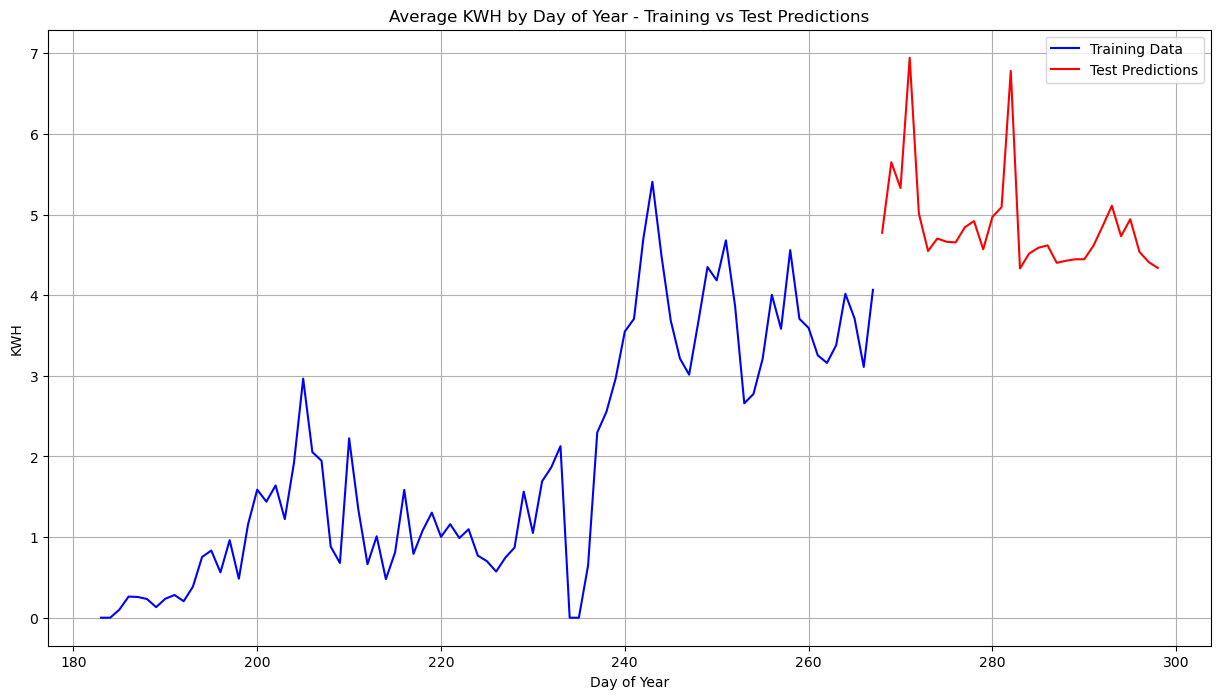

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(15, 8))

# Plot training data
daily_year_avg = train.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=daily_year_avg, x='day_of_year', y='kwh', color='blue', label='Training Data')

# Plot test predictions
test_predictions = pd.DataFrame({
    'day_of_year': test['day_of_year'],
    'kwh': predictions_1
})
test_avg = test_predictions.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=test_avg, x='day_of_year', y='kwh', color='red', label='Test Predictions')

plt.title('Average KWH by Day of Year - Training vs Test Predictions')
plt.xlabel('Day of Year')
plt.ylabel('KWH')
plt.legend()
plt.grid(True)
plt.show()


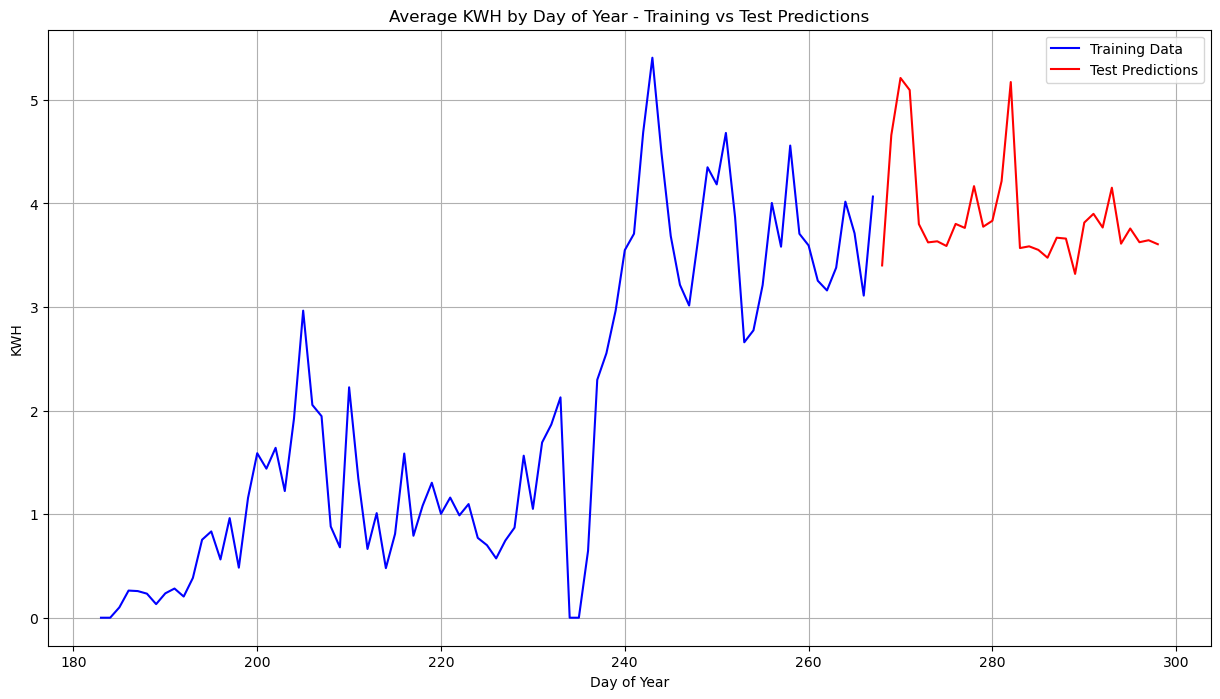

In [149]:
plt.figure(figsize=(15, 8))

# Plot training data
daily_year_avg_ = train.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=daily_year_avg_, x='day_of_year', y='kwh', color='blue', label='Training Data')

# Plot test predictions
test_predictions_ = pd.DataFrame({
    'day_of_year': test['day_of_year'],
    'kwh': predictions_2
})
test_avg_ = test_predictions_.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=test_avg_, x='day_of_year', y='kwh', color='red', label='Test Predictions')

plt.title('Average KWH by Day of Year - Training vs Test Predictions')
plt.xlabel('Day of Year')
plt.ylabel('KWH')
plt.legend()
plt.grid(True)
plt.show()

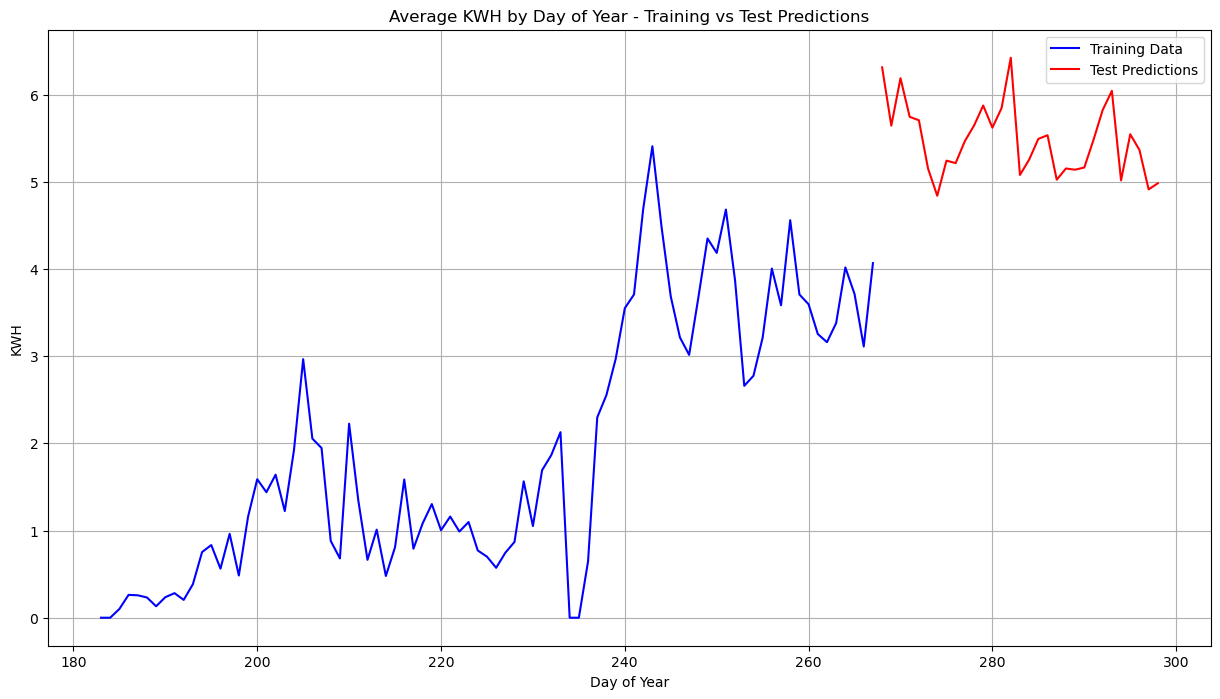

In [150]:
plt.figure(figsize=(15, 8))

# Plot training data
daily_year_avg_0 = train.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=daily_year_avg_0, x='day_of_year', y='kwh', color='blue', label='Training Data')

# Plot test predictions
test_predictions_0 = pd.DataFrame({
    'day_of_year': test['day_of_year'],
    'kwh': predictions_3
})
test_avg_0 = test_predictions_0.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=test_avg_0, x='day_of_year', y='kwh', color='red', label='Test Predictions')

plt.title('Average KWH by Day of Year - Training vs Test Predictions')
plt.xlabel('Day of Year')
plt.ylabel('KWH')
plt.legend()
plt.grid(True)
plt.show()

In [151]:
final_prediction = (predictions_1 + predictions_2 + predictions_3) / 3
final_predictions = (0.5 * predictions_1 + 0.3 * predictions_2 + 0.2 * predictions_3)

In [ ]:
# # Calculate recent performance weights
# recent_errors = [
#     2.76618957442076 ,
#    3.681228332466751,
#     2.702743298266568
# ]
# weights = 1 / np.array(recent_errors)
# weights = weights / weights.sum()  # Normalize

# # Apply time-weighted ensemble
# final_prediction_s = (
#     weights[0] * predictions_1 + 
#     weights[1] * predictions_3 + 
#     weights[2] * predictions_2
# )

In [154]:
last=(final_prediction + final_predictions) / 2

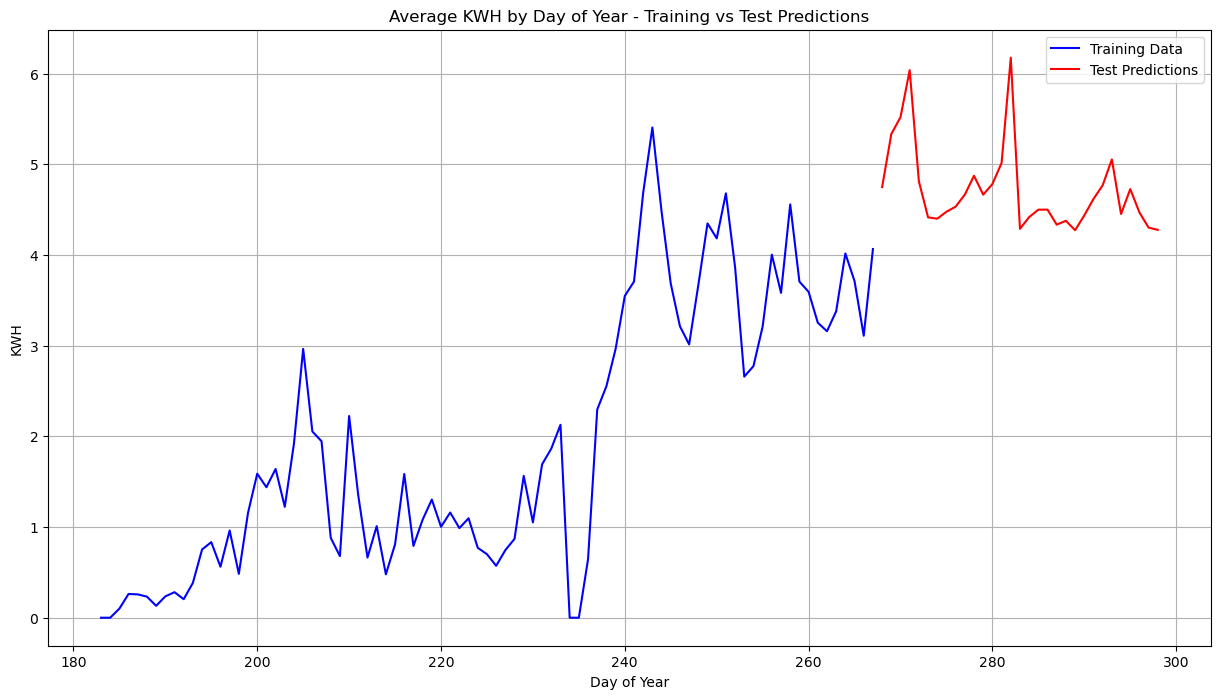

In [155]:
plt.figure(figsize=(15, 8))

# Plot training data
daily_year_avg_1 = train.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=daily_year_avg_1, x='day_of_year', y='kwh', color='blue', label='Training Data')

# Plot test predictions
test_predictions_1 = pd.DataFrame({
    'day_of_year': test['day_of_year'],
    'kwh': last
})
test_avg_1 = test_predictions_1.groupby('day_of_year')['kwh'].mean().reset_index()
sns.lineplot(data=test_avg_1, x='day_of_year', y='kwh', color='red', label='Test Predictions')

plt.title('Average KWH by Day of Year - Training vs Test Predictions')
plt.xlabel('Day of Year')
plt.ylabel('KWH')
plt.legend()
plt.grid(True)
plt.show()

In [156]:
ss.kwh=last

In [157]:

ss.to_csv('ensemble_submission0000.csv', index=False)